In [1]:
import torch
import torchvision

#https://github.com/JohannesTheo/multi_object_datasets_torch
# @misc{multiobjectdatasets19,
#   title={Multi-Object Datasets},
#   author={Kabra, Rishabh and Burgess, Chris and Matthey, Loic and
#           Kaufman, Raphael Lopez and Greff, Klaus and Reynolds, Malcolm and
#           Lerchner, Alexander},
#   howpublished={https://github.com/JohannesTheo/multi_object_datasets_torch},
#   year={2019}
# }
from multi_object_datasets_torch import MultiDSprites ,ClevrWithMasks,Tetrominoes


import model as models
import tqdm
import argparse
import pickle
import matplotlib.pyplot as plt

In [2]:

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

parser = argparse.ArgumentParser()

model_dir='tetrominoes_backboned'
seed=0
batch_size=512
num_slots=4
num_iterations=3
hid_dim=64
learning_rate=10e-3
warmup_steps=2
decay_rate=.6
num_workers=20
num_epochs=1000
decay_steps=num_epochs

parser.add_argument('--model_dir', default=model_dir, type=str, help='where to save models' )
parser.add_argument('--seed', default=seed, type=int, help='random seed')
parser.add_argument('--batch_size', default=batch_size, type=int)
parser.add_argument('--num_slots', default=num_slots, type=int, help='# of slots')
parser.add_argument('--num_iterations', default=num_iterations, type=int, help='# iterations')
parser.add_argument('--hid_dim', default=hid_dim, type=int, help='hidden dimension size')
parser.add_argument('--learning_rate', default=learning_rate, type=float)
parser.add_argument('--warmup_steps', default=warmup_steps, type=int, help='# of warmup steps')
parser.add_argument('--decay_rate', default=decay_rate, type=float, help='decay rate')
parser.add_argument('--decay_steps', default=decay_steps, type=float, help='decay rate')
parser.add_argument('--num_workers', default=num_workers, type=int, help='# of workers for loading data')
parser.add_argument('--num_epochs', default=num_workers, type=int, help='# of epochs')

# opt = parser.parse_args()
# model_dir=opt.model_dir
# seed=opt.seed
# batch_size=opt.batch_size
# num_slots=opt.num_slots
# num_iterations=opt.num_iterations
# hid_dim=opt.hid_dim
# learning_rate=opt.learning_rate
# warmup_steps=opt.warmup_steps
# decay_rate=opt.decay_rate
# num_workers=opt.num_workers
# num_epochs=opt.num_epochs

_StoreAction(option_strings=['--num_epochs'], dest='num_epochs', nargs=None, const=None, default=20, type=<class 'int'>, choices=None, required=False, help='# of epochs', metavar=None)

In [3]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.ConvertImageDtype(torch.float32),
])


In [4]:
train_set=Tetrominoes("data/Tetrominoes",download=True)
train_dataloader=torch.utils.data.DataLoader(train_set,batch_size=batch_size,shuffle=True,num_workers=num_workers)

tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0

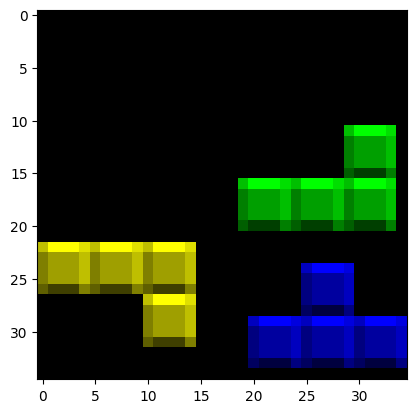

In [5]:
torch.manual_seed(seed)

visual=transform(train_set[0]['image'].unsqueeze(0)).to(device)
plt.imshow(visual.detach().to('cpu')[0,:,:,:].permute(1,2,0))
print(visual)

In [6]:
model=models.AutoEncoder(target_resolution=(35,35),base_resolution=(5,5),slot_iterations=num_iterations,stepsize=2,just_alpha=False,n_slots=num_slots).to(device)

In [7]:
def lr_sched(epoch):
    epoch+=1
    lr=learning_rate
    if epoch<warmup_steps:
        lr=lr/(epoch/warmup_steps)
    lr*=decay_rate**(epoch/decay_steps)
    return lr

In [8]:
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)
crit=torch.nn.MSELoss()
sched=torch.optim.lr_scheduler.LambdaLR(optimizer,lr_sched)

In [9]:
iteration=0
loss_evolution=[]
for epohc in range(num_epochs):
    closs=0
    for idx,batch in enumerate(tqdm.tqdm(train_dataloader)):

        images=transform(batch['image']).to(device)

        optimizer.zero_grad()
        recon=model(images)
        loss=crit(recon,images)
        loss.backward()
        optimizer.step()
        
        closs+=loss.detach()
        del loss,recon,images
    loss_evolution+=[closs/len(train_dataloader)]
    sched.step()
    print(f"loss: {closs}, epoch:{epohc}/{num_epochs}")
    ##
    with torch.no_grad():
        plt.imshow(model(visual).detach().to('cpu')[0,:,:,:].permute(1,2,0))
        plt.show()
    ##
    if epohc%10==0:
        torch.save(model.state_dict(), model_dir+"/autosave.pt")
        with open(model_dir+'/stats.pkl', mode='wb') as file:
            pickle.dump(loss_evolution,file)

 20%|█▉        | 35/176 [00:21<01:28,  1.60it/s]


KeyboardInterrupt: 

In [ ]:
torch.save(model.state_dict(), model_dir+"/epoch264+29perfinal.pt")